The pr-work #5

First name - Rodion

Second name - Ostapenko

Group - CS-24

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy.signal as signal
from scipy.integrate import odeint

### Load & prepare the data

In [78]:
df = pd.read_csv(r'\src\CrabAgePrediction.csv')
# converting values into units of measurement we are more familiar with
df['Length'] = df['Length'] * 30.48 #foot to cm
df['Height'] = df['Height'] * 30.48
df['Diameter'] = df['Diameter'] * 30.48
df['Weight'] = df['Weight'] * 28.34 #ounces to grams
df['Shucked Weight'] = df['Shucked Weight'] * 28.34
df['Viscera Weight'] = df['Viscera Weight'] * 28.34
df['Shell Weight'] = df['Shell Weight'] * 28.34
df.head(10)

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,43.815,35.814,12.573,698.176177,349.489801,158.274692,191.215110,9
1,M,27.051,19.812,6.477,153.052430,65.077411,38.966104,44.188366,6
2,I,31.623,23.622,7.620,225.360665,91.590431,45.393503,78.333921,6
3,F,35.814,27.051,7.620,382.028507,134.573659,64.675699,148.633594,10
4,I,27.051,20.193,6.477,195.633946,98.017829,42.179804,48.205490,6
5,F,47.244,35.433,10.668,812.262503,384.840494,191.616822,204.873332,8
6,F,39.624,30.480,9.906,501.738806,172.736338,165.907227,136.582221,15
7,M,40.386,30.861,11.430,668.047746,282.805540,150.240443,202.864770,10
8,I,48.387,38.100,12.573,1196.299572,574.448753,276.779854,290.438076,13
9,I,27.813,20.955,10.287,192.821959,86.769882,35.752405,59.051725,7


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   str    
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 273.9 KB


## I. Base visualization with Matplotlib

Text(0, 0.5, 'Count')

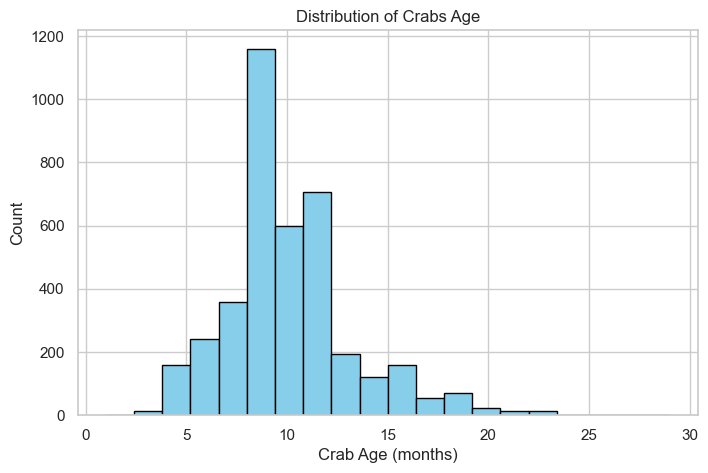

In [80]:
plt.figure(figsize=(8, 5))

plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Crabs Age')
plt.xlabel('Crab Age (months)')
plt.ylabel('Count')

#### The plot shows the number of records for each crab age, which is important to know about 
#### the dataset because the more data there is, the better the model can be trained to identify a specific age

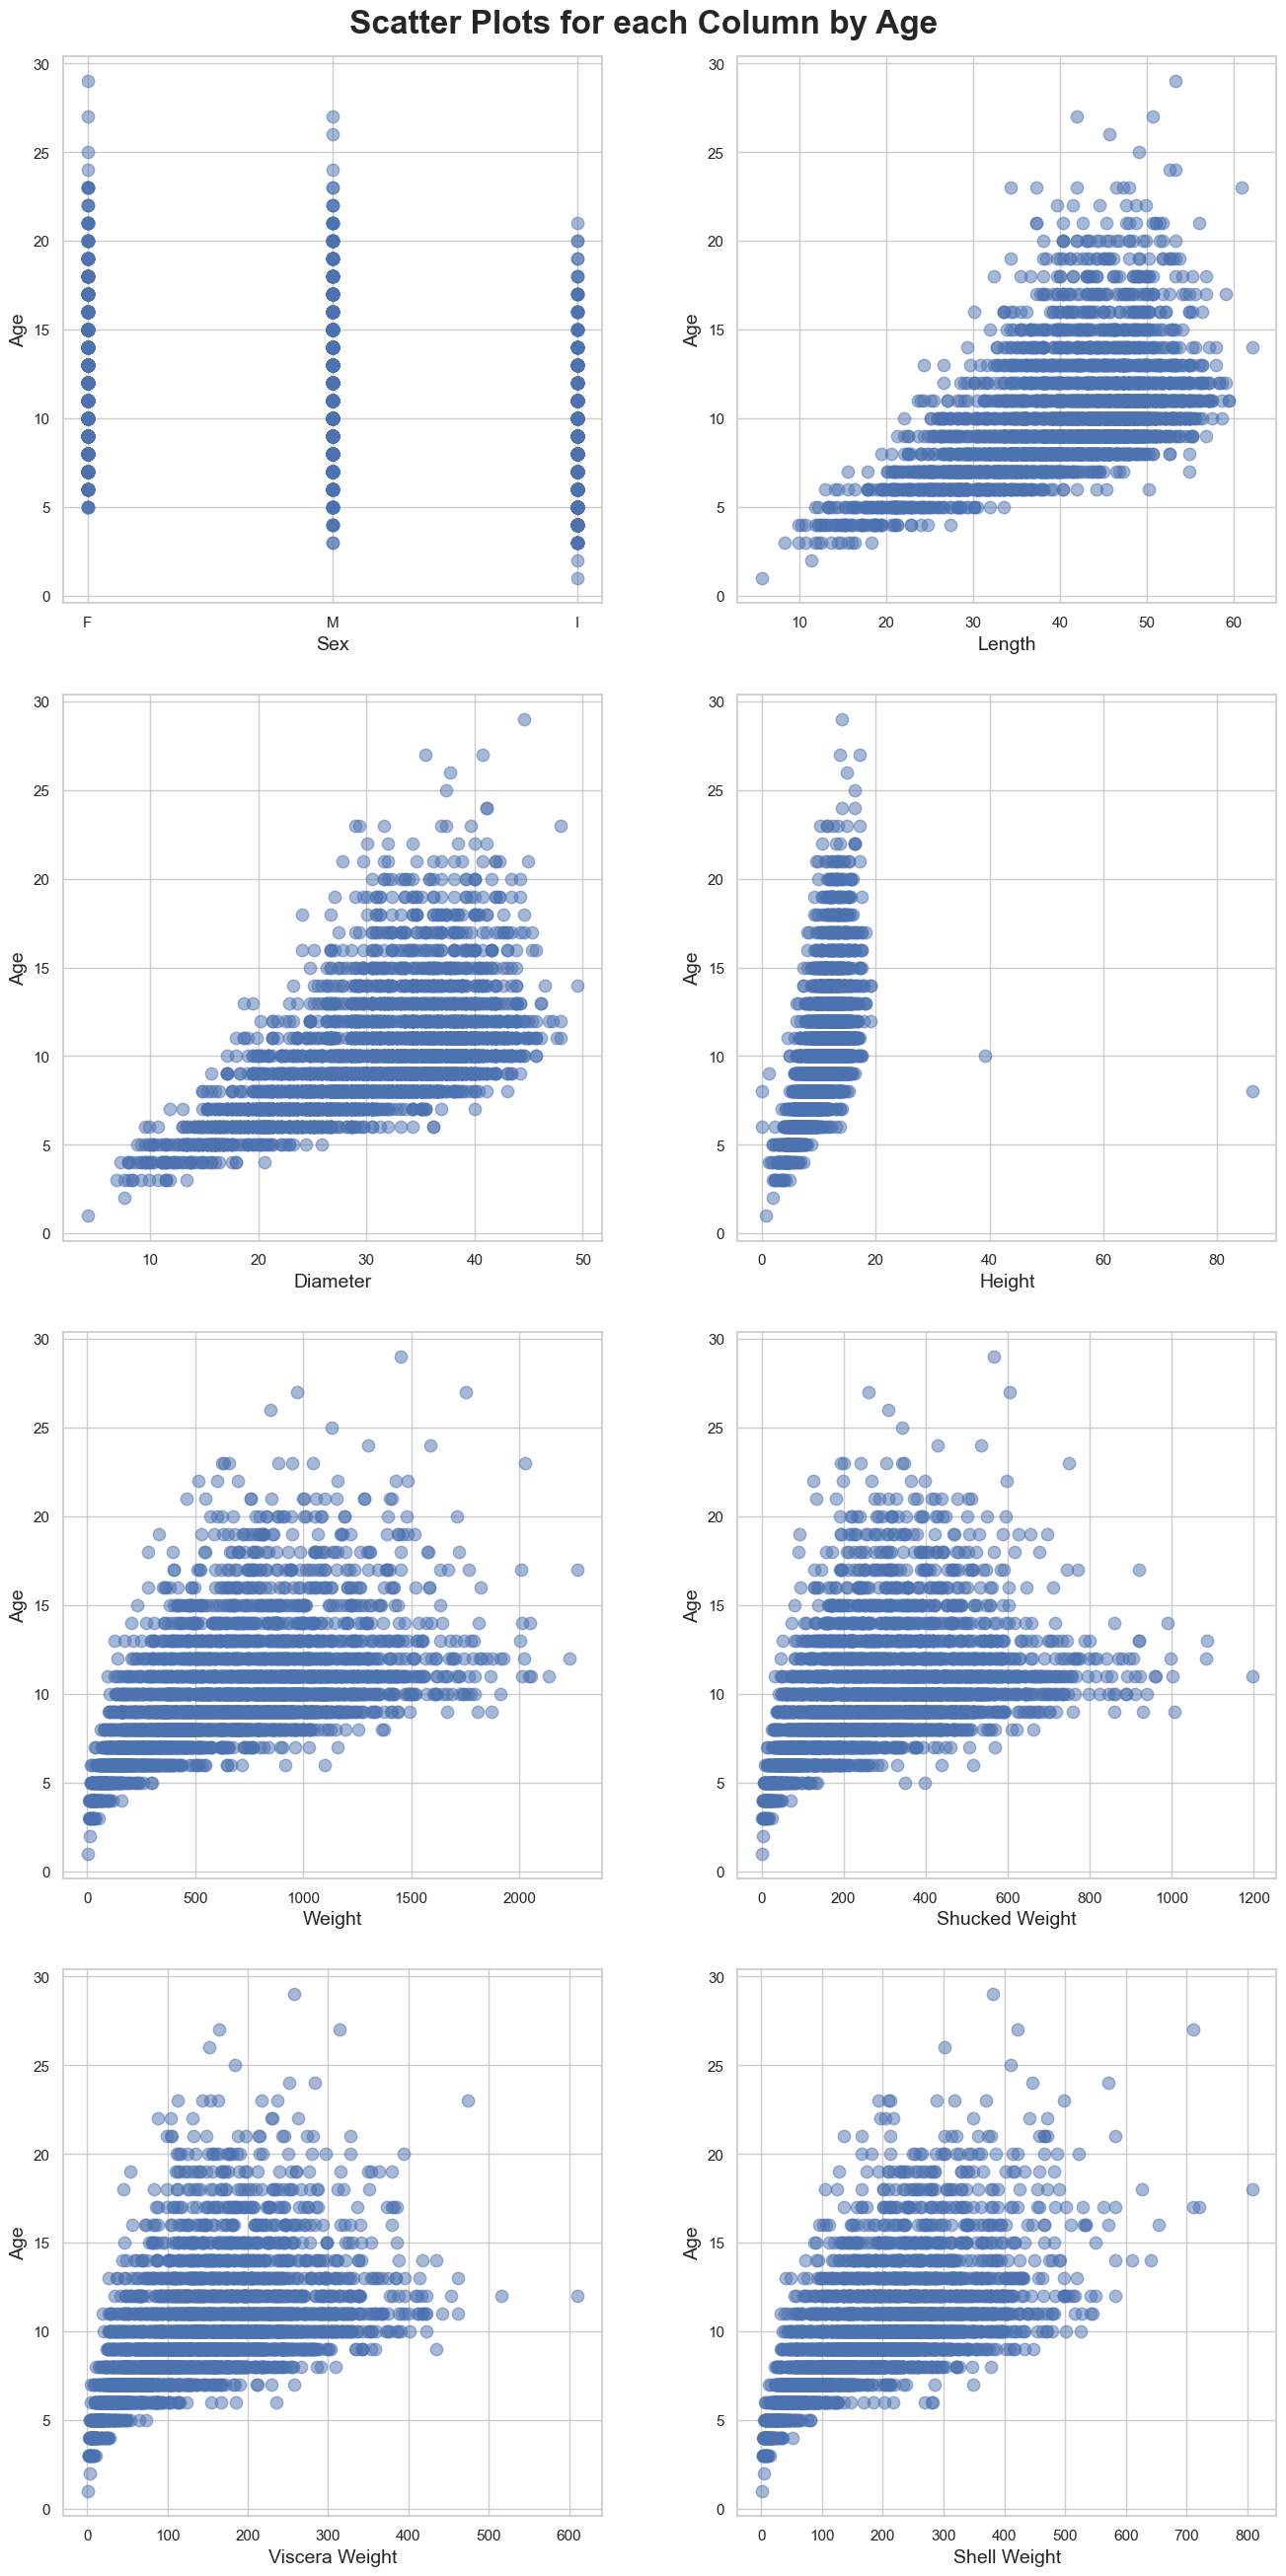

In [81]:
target_col = 'Age'

size=13
cols = df.columns.drop([target_col])
n_cols = 2
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(size, size/n_cols*n_rows))
fig.suptitle(f'Scatter Plots for each Column by Age', fontsize=24, fontweight='bold', y=1)

axes_flat = axes.flatten()

for i, col in enumerate(cols):
    ax = axes_flat[i]

    ax.scatter(df[col], df[target_col], s=80, alpha=0.5)

    ax.set_xlabel(f'{col}', fontsize=14)
    ax.set_ylabel(f'{target_col}', fontsize=14)

plt.tight_layout(pad=0.5, h_pad=2.5, w_pad=5)
plt.show()



#### The plots show a direct correlation between each crab characteristic and its age, 
#### making it possible to identify certain patterns and spot outliers, as is clearly evident in the plot showing height

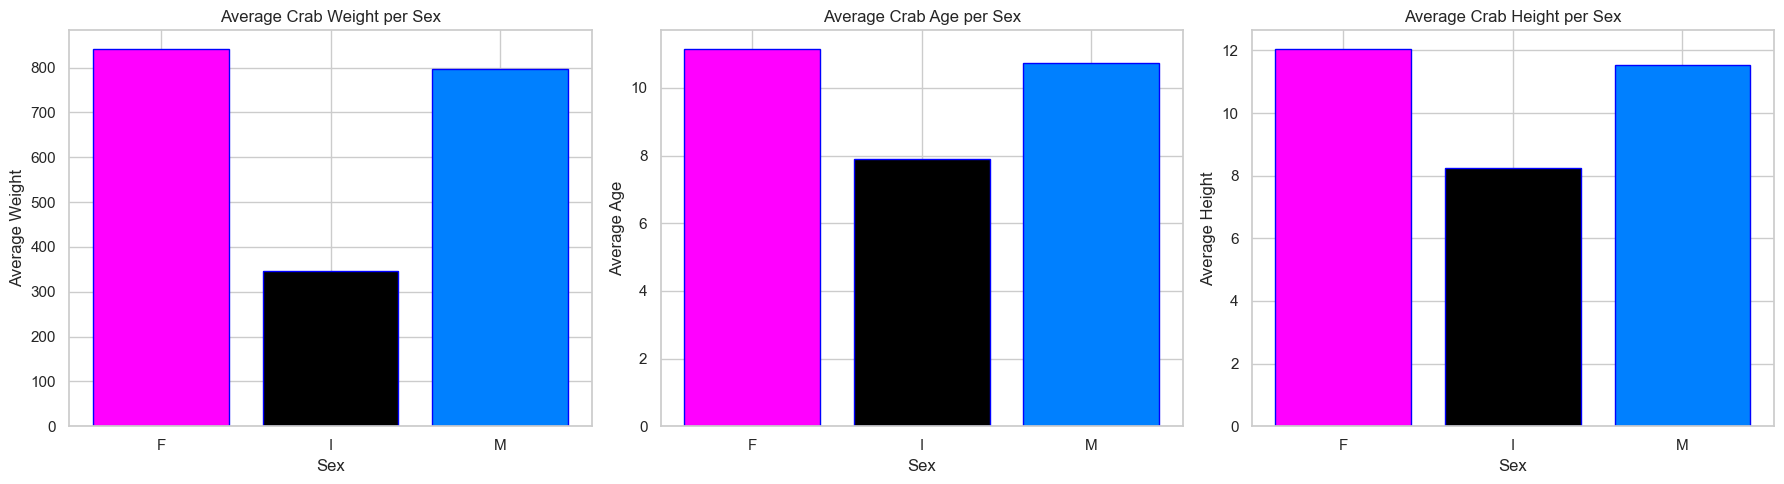

In [82]:
metrics = ['Weight', 'Age', 'Height']
mean_values = df.groupby('Sex')[metrics].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#FF00FF', '#000000', '#0080FF']

for i, metric in enumerate(metrics):
    axes[i].bar(['F', 'I', 'M'], mean_values[metric], 
                color=colors, edgecolor='blue')
    
    axes[i].set_title(f'Average Crab {metric} per Sex')
    axes[i].set_xlabel('Sex')
    axes[i].set_ylabel(f'Average {metric}')

plt.tight_layout()
plt.savefig('crab_metrics_plots.png')

#### Since the average age plot is directly proportional to the others, the differences between crabs 
#### are almost entirely unrelated to sex; the entire difference lies in age

## II. Advanced visualizations with Seaborn

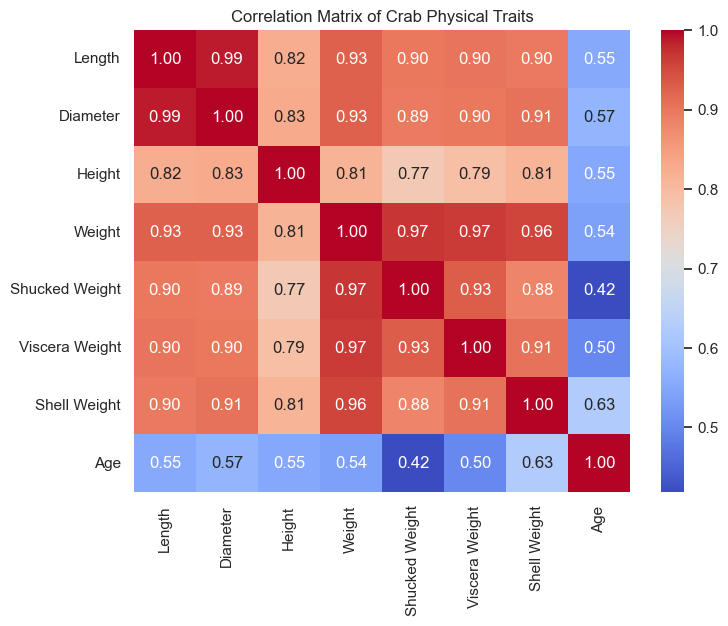

In [83]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Crab Physical Traits')
plt.show()

#### This correlation matrix helps quickly identify which columns are most closely related
#### For example, it shows that Diameter and Length are almost 100% correlated
#### And for determining age, for instance, Shell Weight is the most suitable measure

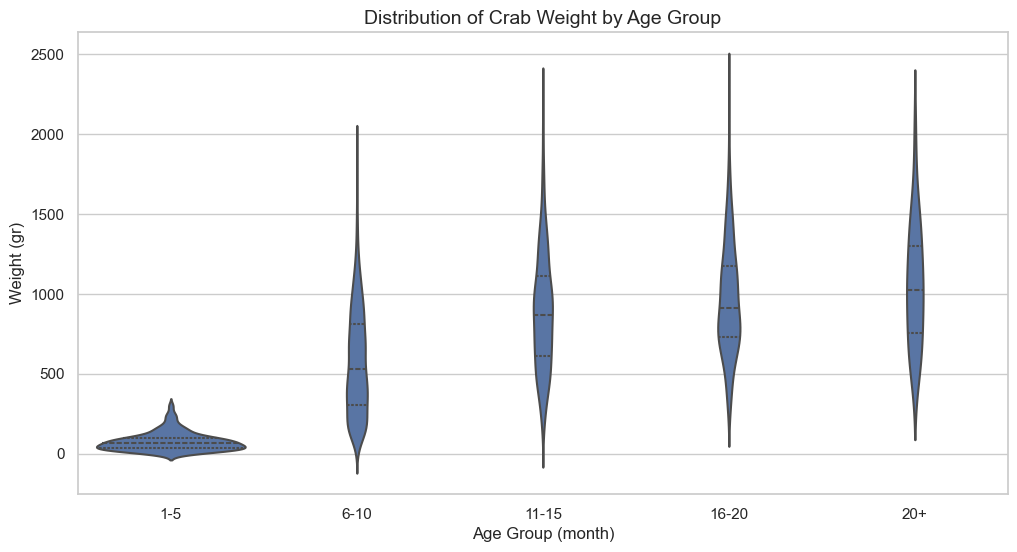

In [84]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 5, 10, 15, 20, 30], 
                         labels=['1-5', '6-10', '11-15', '16-20', '20+'])

sns.set_theme(style="whitegrid") 

plt.figure(figsize=(12, 6))

sns.violinplot(data=df, x='Age_Group', y='Weight', inner='quartile', linewidth=1.5)
plt.title('Distribution of Crab Weight by Age Group', fontsize=14)
plt.xlabel('Age Group (month)', fontsize=12)
plt.ylabel('Weight (gr)', fontsize=12)
plt.show()

#### This graph shows a more detailed breakdown of weight by age group
#### The graph also displays the medians within the violin plots themselves
#### The presence of outliers is also clearly visible here

## III. Advanced interactive visualization with Plotly

In [93]:
fig1 = px.scatter(
    df,
    x='Length',
    y='Weight',
    color='Sex',
    hover_data={
        'Sex': True,
        'Length': True,
        'Weight': True,
        'Age': True,
        'Diameter': True,
        'Height': True
    },
    title='Scatter plot of Length vs. Weight, colored by Sex',
    labels={
        'Length': 'Length (cm)', 
        'Weight': 'Weight (gr)'
    },
    opacity=0.4
)

fig1.show()

#### Additional information is provided when you hover over a specific point
#### Plotly also allows a rectangle zoom to see deeply into specific clusters

In [103]:
fig2 = go.Figure()

weight_columns = ['Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight']

#trace for each weight column
for col in weight_columns:
    fig2.add_trace(
        go.Box(
            x=df['Age_Group'],
            y=df[col],
            name=col,
            hovertext=df['Sex'], 
            hovertemplate='<b>Age Group:</b> %{x}<br>' +
                          '<b>Weight:</b> %{y}<br>' +
                          '<b>Sex:</b> %{hovertext}<extra></extra>',
            visible=(col == 'Weight') 
        )
    )

#dropdown buttons
buttons = []
for i, col in enumerate(weight_columns):
    #array of booleans determining which trace is visible
    visibility = [False] * len(weight_columns)
    visibility[i] = True
    
    button = dict(
        label=col,
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Distribution of {col} by Age Group",
             "yaxis": {"title": f"{col} (g)"}}
        ]
    )
    buttons.append(button)

#the dropdown menu 
fig2.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.108,
            y=1.15
        )
    ],
    title="Distribution of Weight by Age Group",
    xaxis_title="Age Group",
    yaxis_title="Weight (g)",
    boxmode='group'
)

fig2.show()

#### Interactive dropdown menu + useful data when hovering

## IV. Producing animations with Matplotlib

### 1. Fourier Series Square Wave Synthesis 

In [107]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 4 * np.pi, 1000)

#Target square wave in the background
target_sq_wave = signal.square(x)
ax.plot(x, target_sq_wave, color='lightgray', lw=4, label='Target Square Wave')

ax.set_xlim(0, 4 * np.pi)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

#Create an empty line object for the Fourier approximation
line, = ax.plot([], [], color='red', lw=2)

#Initialization function
def init():
    line.set_data([], [])
    ax.set_title("Fourier Series Approximation: N=0 terms")
    return line,

#Update function: frame represents the number of harmonics n
def update(frame):
    y = np.zeros_like(x)
    for k in range(1, frame + 1):
        n = 2 * k - 1
        y += (4 / np.pi) * (1 / n) * np.sin(n * x)
    
    line.set_data(x, y)
    ax.set_title(f"Fourier Series Approximation: N={frame} terms")
    return line,

ani_fourier = FuncAnimation(fig, update, frames=np.arange(1, 31),
                            init_func=init, blit=False, interval=200)

plt.close(fig)
HTML(ani_fourier.to_jshtml())

### The Lorenz Attractor (Chaos Theory) 

In [115]:
#Define the Lorenz System of Differential Equations
def lorenz(state, t, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

#Pre-calculate the trajectory
t = np.linspace(0, 25, 2000) #Time steps
initial_state = [1.0, 1.0, 1.0] #Starting position
sigma, rho, beta = 10.0, 28.0, 8.0/3.0

trajectory = odeint(lorenz, initial_state, t, args=(sigma, rho, beta))
x_data, y_data, z_data = trajectory.T

#Set up the 3D figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

#Styling
ax.set_axis_off()
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

#Strict limits based on the data to prevent camera jumping
ax.set_xlim(min(x_data), max(x_data))
ax.set_ylim(min(y_data), max(y_data))
ax.set_zlim(min(z_data), max(z_data))

#Create the empty line object
line, = ax.plot([], [], [], color='cyan', lw=0.8, alpha=0.8)

#Dynamic Title text object
title = ax.set_title("", color='white', fontsize=14)

def init():
    line.set_data([], [])
    line.set_3d_properties([])
    title.set_text("")
    return line, title

#Update function frame is the index of the current time step
def update(frame):
    #Slicing the arrays up to the current frame to draw the path over time
    line.set_data(x_data[:frame], y_data[:frame])
    line.set_3d_properties(z_data[:frame])
    
    title.set_text(f"Lorenz Attractor | t = {t[frame]:.2f}")
    return line, title

#Create the animation (skip every 10 frames to make the animation play faster)
ani_lorenz = FuncAnimation(fig, update, frames=range(0, len(t), 10),
                           init_func=init, blit=False, interval=30)

plt.close(fig)
HTML(ani_lorenz.to_jshtml())